# Phase 2: Data Understanding

**CRISP-DM Phase Description:**  
This phase involves acquiring the data, getting familiar with it, identifying data quality problems, and detecting initial insights. A thorough understanding of the data at this stage is critical for a successful project.

---

In [1]:
# Standard library imports for this phase
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid")


---
### Task 1: Collect Initial Data

Acquire the necessary data and load it into the analysis environment. This task includes:

- **Data Acquisition:** Load data from files, databases, APIs, or other sources.
- **Initial Data Report:** Document the data source(s), the method of acquisition, and any problems encountered during loading.

**Instructions:**
1. Update the file path(s) below to point to your actual dataset(s).
2. Load the data into a Pandas DataFrame.
3. Display a small sample of the data to confirm it loaded correctly.

In [2]:
DATA_PATH = Path("..") / "data" / "raw" / "WA_Fn-UseC_-HR-Employee-Attrition.csv"
df = pd.read_csv(DATA_PATH)

print(f"Loaded dataset from: {DATA_PATH.resolve()}")
df.head()


Loaded dataset from: C:\vscode\workspace\ds\CRISP-DM Guiding Notebooks-20260415\data\raw\WA_Fn-UseC_-HR-Employee-Attrition.csv


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [3]:
print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Attrition rate: {(df['Attrition'].eq('Yes').mean() * 100):.2f}%")

df.sample(5, random_state=42)


Dataset shape: 1470 rows x 35 columns
Attrition rate: 16.12%


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1041,28,No,Travel_Rarely,866,Sales,5,3,Medical,1,1469,4,Male,84,3,2,Sales Executive,1,Single,8463,23490,0,Y,No,18,3,4,80,0,6,4,3,5,4,1,3
184,53,No,Travel_Rarely,1084,Research & Development,13,2,Medical,1,250,4,Female,57,4,2,Manufacturing Director,1,Divorced,4450,26250,1,Y,No,11,3,3,80,2,5,3,3,4,2,1,3
1222,24,Yes,Travel_Rarely,240,Human Resources,22,1,Human Resources,1,1714,4,Male,58,1,1,Human Resources,3,Married,1555,11585,1,Y,No,11,3,3,80,1,1,2,3,1,0,0,0
67,45,No,Travel_Rarely,1339,Research & Development,7,3,Life Sciences,1,86,2,Male,59,3,3,Research Scientist,1,Divorced,9724,18787,2,Y,No,17,3,3,80,1,25,2,3,1,0,0,0
220,36,No,Travel_Rarely,1396,Research & Development,5,2,Life Sciences,1,304,4,Male,62,3,2,Laboratory Technician,2,Single,5914,9945,8,Y,No,16,3,4,80,0,16,3,4,13,11,3,7


In [4]:
data_source_report = {
    "source": "IBM HR Analytics Employee Attrition & Performance dataset",
    "acquisition_method": "Local CSV file added to the project repository",
    "storage_location": str(DATA_PATH),
    "records": int(df.shape[0]),
    "attributes": int(df.shape[1]),
    "target_variable": "Attrition",
    "notes": [
        "Each row represents one employee.",
        "The dataset is static and does not contain event timestamps.",
        "Several columns are ordinal survey-style ratings on 1-4 scales.",
    ],
}

data_source_report


{'source': 'IBM HR Analytics Employee Attrition & Performance dataset',
 'acquisition_method': 'Local CSV file added to the project repository',
 'storage_location': '..\\data\\raw\\WA_Fn-UseC_-HR-Employee-Attrition.csv',
 'records': 1470,
 'attributes': 35,
 'target_variable': 'Attrition',
 'notes': ['Each row represents one employee.',
  'The dataset is static and does not contain event timestamps.',
  'Several columns are ordinal survey-style ratings on 1-4 scales.']}

---
### Task 2: Describe Data

Examine the "surface" properties of the acquired data. This includes:

- **Volume:** How many records (rows) and attributes (columns) does the dataset contain?
- **Field Identities:** What are the names, data types, and roles (ID, feature, target) of each column?
- **Descriptive Statistics:** What are the basic statistics (mean, median, std, min, max) of the numerical features and frequency counts for categorical features?

**Instructions:** Use Pandas built-in methods (`.info()`, `.describe()`, `.dtypes`, `.value_counts()`) to generate a comprehensive description of your data.

In [5]:
schema_summary = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "non_null": df.notna().sum(),
        "missing_pct": (df.isna().mean() * 100).round(2),
        "n_unique": df.nunique(),
    }
).sort_index()

schema_summary


,dtype,non_null,missing_pct,n_unique
Age,int64,1470,0.0,43
Attrition,object,1470,0.0,2
BusinessTravel,object,1470,0.0,3
DailyRate,int64,1470,0.0,886
Department,object,1470,0.0,3
DistanceFromHome,int64,1470,0.0,29
Education,int64,1470,0.0,5
EducationField,object,1470,0.0,6
EmployeeCount,int64,1470,0.0,1
EmployeeNumber,int64,1470,0.0,1470


In [6]:
numerical_summary = df.describe().T.sort_index()
numerical_summary


,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


In [7]:
categorical_summary = df.describe(include="object").T

value_count_snapshots = {
    col: df[col].value_counts().head(5).to_dict()
    for col in ["Attrition", "Department", "JobRole", "OverTime", "BusinessTravel"]
}

categorical_summary, value_count_snapshots


(               count unique                     top  freq
 Attrition       1470      2                      No  1233
 BusinessTravel  1470      3           Travel_Rarely  1043
 Department      1470      3  Research & Development   961
 EducationField  1470      6           Life Sciences   606
 Gender          1470      2                    Male   882
 JobRole         1470      9         Sales Executive   326
 MaritalStatus   1470      3                 Married   673
 Over18          1470      1                       Y  1470
 OverTime        1470      2                      No  1054,
 {'Attrition': {'No': 1233, 'Yes': 237},
  'Department': {'Research & Development': 961,
   'Sales': 446,
   'Human Resources': 63},
  'JobRole': {'Sales Executive': 326,
   'Research Scientist': 292,
   'Laboratory Technician': 259,
   'Manufacturing Director': 145,
   'Healthcare Representative': 131},
  'OverTime': {'No': 1054, 'Yes': 416},
  'BusinessTravel': {'Travel_Rarely': 1043,
   'Travel_Frequent

---
### Task 3: Explore Data

Dig deeper into the data using querying, visualisation, and statistical analysis to find initial insights, patterns, and interesting subsets. Key activities include:

- **Univariate Analysis:** Examine the distribution of individual features using histograms, box plots, and bar charts.
- **Bivariate / Multivariate Analysis:** Explore relationships between features using scatter plots, correlation matrices, and grouped summaries.
- **Initial Hypotheses:** Formulate initial hypotheses based on observed patterns.

**Instructions:** Create visualisations and run queries to understand the distributions, relationships, and patterns in your data.

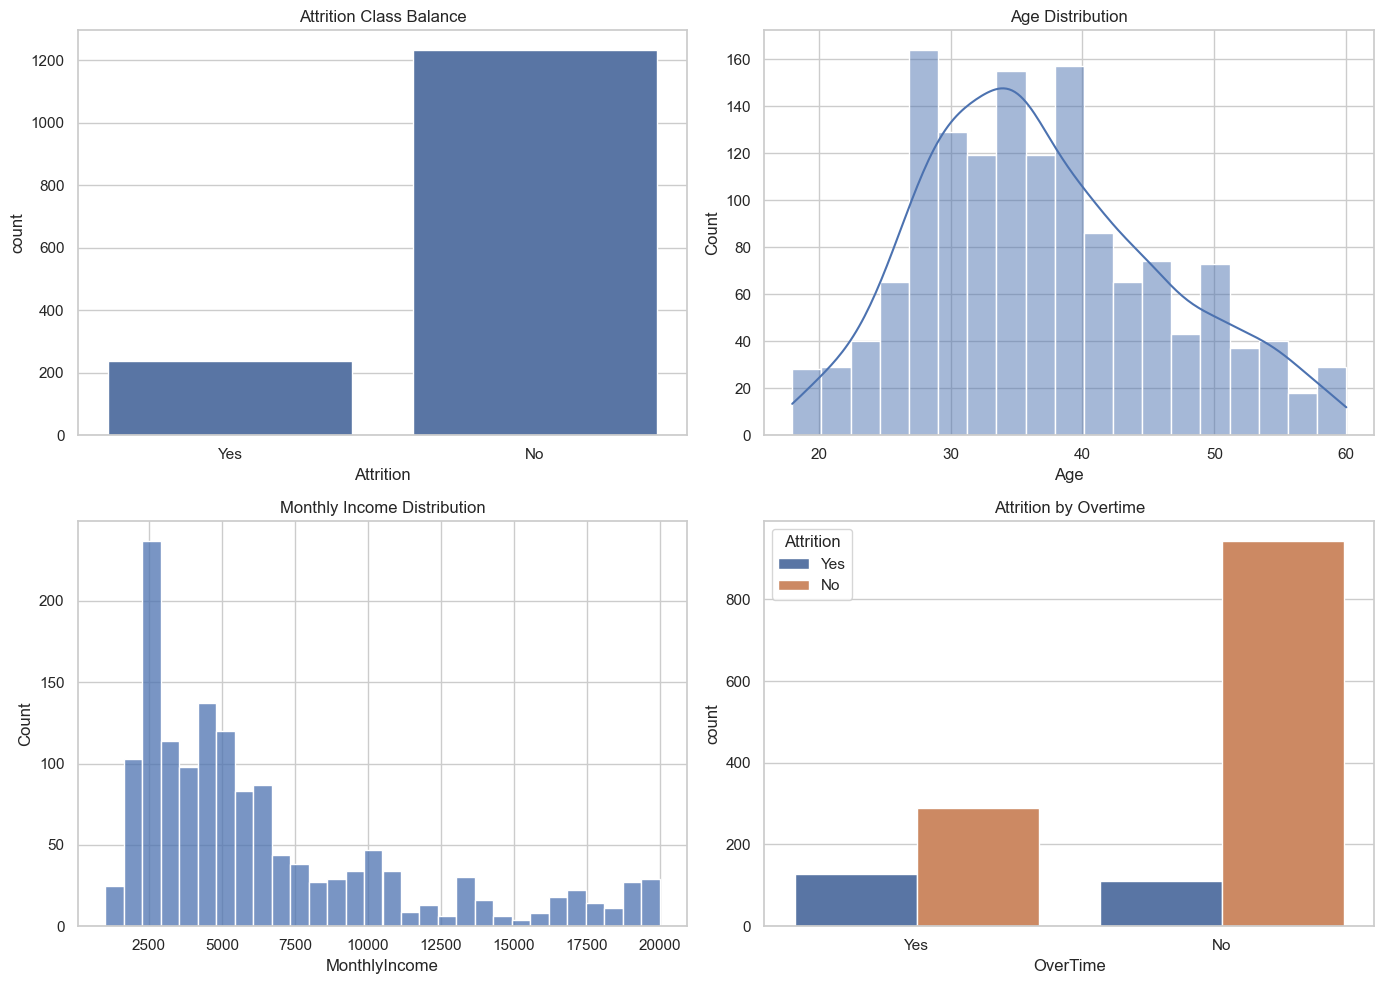

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(data=df, x="Attrition", ax=axes[0, 0])
axes[0, 0].set_title("Attrition Class Balance")

sns.histplot(data=df, x="Age", kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Age Distribution")

sns.histplot(data=df, x="MonthlyIncome", bins=30, ax=axes[1, 0])
axes[1, 0].set_title("Monthly Income Distribution")

sns.countplot(data=df, x="OverTime", hue="Attrition", ax=axes[1, 1])
axes[1, 1].set_title("Attrition by Overtime")

plt.tight_layout()
plt.show()


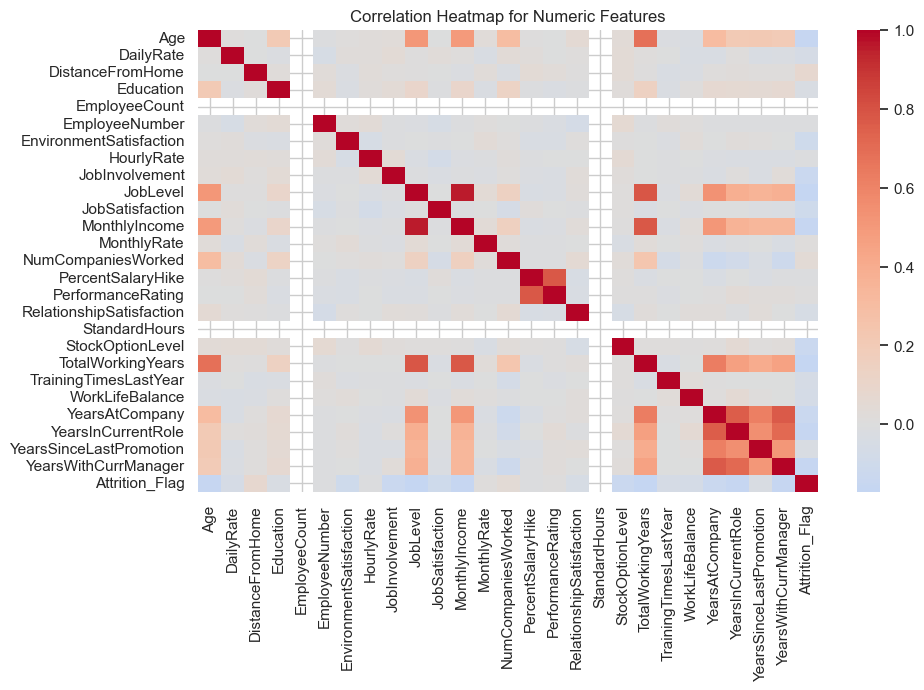

(Department
 Sales                     0.206278
 Human Resources           0.190476
 Research & Development    0.138398
 Name: Attrition, dtype: float64,
 JobRole
 Sales Representative         0.397590
 Laboratory Technician        0.239382
 Human Resources              0.230769
 Sales Executive              0.174847
 Research Scientist           0.160959
 Manufacturing Director       0.068966
 Healthcare Representative    0.068702
 Manager                      0.049020
 Research Director            0.025000
 Name: Attrition, dtype: float64,
 Attrition_Flag             1.000000
 DistanceFromHome           0.077924
 NumCompaniesWorked         0.043494
 MonthlyRate                0.015170
 PerformanceRating          0.002889
 HourlyRate                -0.006846
 EmployeeNumber            -0.010577
 PercentSalaryHike         -0.013478
 Education                 -0.031373
 YearsSinceLastPromotion   -0.033019
 Name: Attrition_Flag, dtype: float64,
 YearsAtCompany         -0.134392
 StockOpt

In [9]:
attrition_by_department = (
    df.groupby("Department")["Attrition"]
    .apply(lambda s: s.eq("Yes").mean())
    .sort_values(ascending=False)
)

attrition_by_job_role = (
    df.groupby("JobRole")["Attrition"]
    .apply(lambda s: s.eq("Yes").mean())
    .sort_values(ascending=False)
    .head(10)
)

numeric_corr = (
    df.assign(Attrition_Flag=df["Attrition"].eq("Yes").astype(int))
    .select_dtypes(include=np.number)
    .corr()["Attrition_Flag"]
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))
sns.heatmap(
    df.assign(Attrition_Flag=df["Attrition"].eq("Yes").astype(int))
    .select_dtypes(include=np.number)
    .corr(),
    cmap="coolwarm",
    center=0,
)
plt.title("Correlation Heatmap for Numeric Features")
plt.show()

attrition_by_department, attrition_by_job_role, numeric_corr.head(10), numeric_corr.tail(10)


In [10]:
initial_insights = [
    "Attrition is a minority class, so accuracy alone will be misleading.",
    "Overtime is likely to be an important attrition driver because leavers are often concentrated in the 'Yes' group.",
    "Role and department appear to matter, which supports targeted retention strategies rather than one company-wide action.",
    "Tenure and promotion-related variables are plausible proxies for career stagnation risk.",
]

for index, insight in enumerate(initial_insights, start=1):
    print(f"{index}. {insight}")


1. Attrition is a minority class, so accuracy alone will be misleading.
2. Overtime is likely to be an important attrition driver because leavers are often concentrated in the 'Yes' group.
3. Role and department appear to matter, which supports targeted retention strategies rather than one company-wide action.
4. Tenure and promotion-related variables are plausible proxies for career stagnation risk.


---
### Task 4: Verify Data Quality

Evaluate the completeness and correctness of the data. Check for problems that could affect the analysis:

- **Missing Values:** Identify columns with missing data, the volume, and patterns of missingness.
- **Duplicates:** Check for and report duplicate records.
- **Outliers:** Detect anomalous values using statistical methods or visualisations (box plots, z-scores).
- **Inconsistencies:** Look for data type mismatches, inconsistent formatting, or invalid entries.

**Instructions:** Systematically check for data quality issues and document your findings.

In [11]:
missing_report = pd.DataFrame(
    {
        "missing_count": df.isna().sum(),
        "missing_pct": (df.isna().mean() * 100).round(2),
    }
).sort_values(["missing_count", "missing_pct"], ascending=False)

missing_report[missing_report["missing_count"] > 0].head(10)


,missing_count,missing_pct


In [12]:
duplicates = int(df.duplicated().sum())
constant_columns = [col for col in df.columns if df[col].nunique(dropna=False) == 1]

quality_overview = {
    "duplicate_rows": duplicates,
    "constant_columns": constant_columns,
}

quality_overview


{'duplicate_rows': 0,
 'constant_columns': ['EmployeeCount', 'Over18', 'StandardHours']}

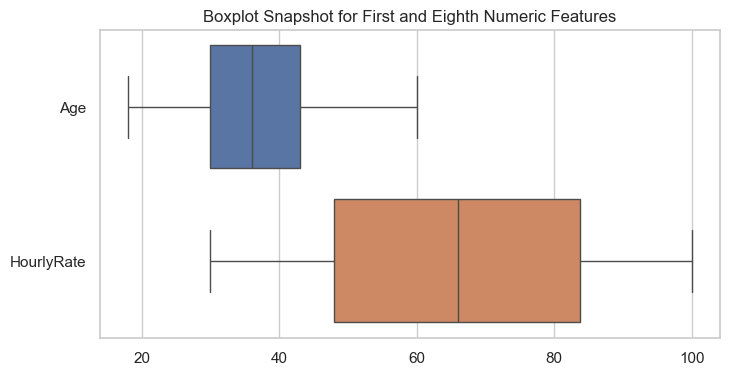

In [13]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
selected_cols = [numeric_cols[0], numeric_cols[7]] if len(numeric_cols) >= 8 else numeric_cols
outlier_rows = []

for col in selected_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = int(((df[col] < lower) | (df[col] > upper)).sum())
    outlier_rows.append({"feature": col, "iqr_outlier_count": count})


plt.figure(figsize=(8, 4))
sns.boxplot(data=df[selected_cols], orient="h")
plt.title("Boxplot Snapshot for First and Eighth Numeric Features")
plt.show()
